     Optimal Portfolio (Maximum Sharpe Ratio)     
Annualized Return: 2009.71 %
Annualized Volatility: 2010.03 %
Sharpe Ratio: 1.0

Allocation:
              allocation
stock_symbol            
ICICIBANK.NS       12.49
INFY.NS            41.30
MARUTI.NS          18.02
SUNPHARMA.NS       11.32
TATASTEEL.NS       16.88


     Minimum Volatility Portfolio     
Annualized Return: 1719.63 %
Annualized Volatility: 1857.1 %
Sharpe Ratio: 0.92

Allocation:
              allocation
stock_symbol            
ICICIBANK.NS       11.18
INFY.NS            33.82
MARUTI.NS          24.37
SUNPHARMA.NS       26.29
TATASTEEL.NS        4.34


C:\Users\hlamb\AppData\Local\Temp\ipykernel_7876\1443265954.py:87: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  plt.scatter(max_sharpe_port[1], max_sharpe_port[0], marker='*', color='r', s=500, label='Maximum Sharpe Ratio')
C:\Users\hlamb\AppData\Local\Temp\ipykernel_7876\1443265954.py:88: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  plt.scatter(min_vol_port[1], min_vol_port[0], marker='*', color='g', s=500, label='Minimum Volatility')


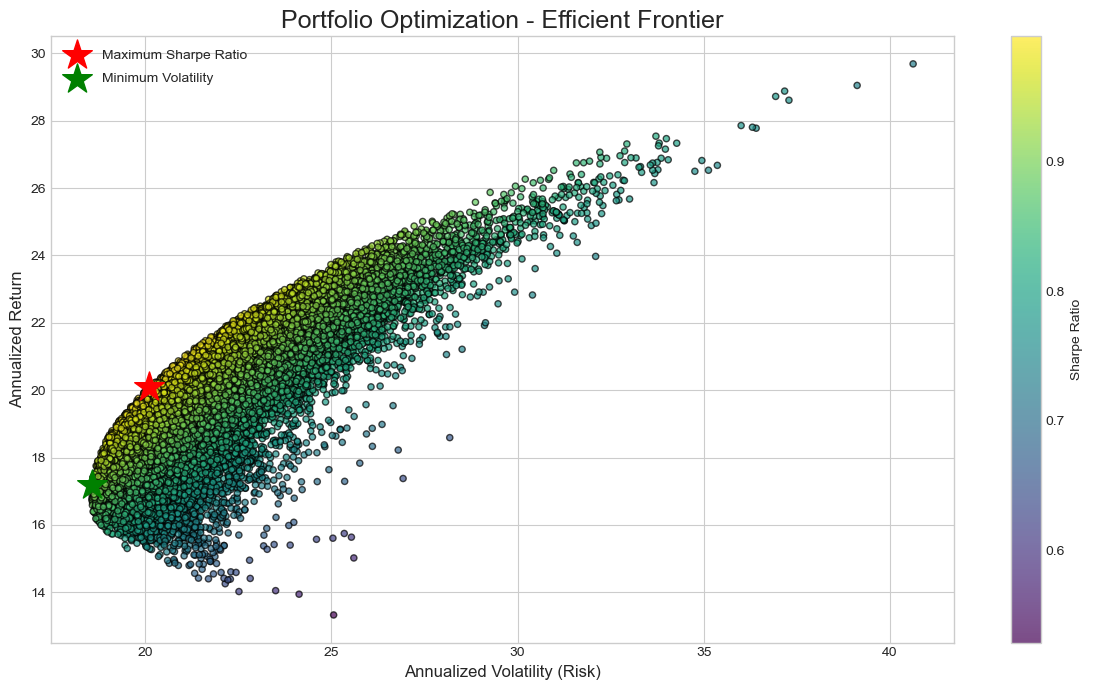

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Step 1: Load and Prepare Data
df = pd.read_csv('stock_prices_cleaned.csv', parse_dates=['trade_date'])

# Create a pivot table with dates as index, symbols as columns, and daily returns as values
returns_df = df.pivot_table(index='trade_date', columns='stock_symbol', values='daily_return_pct')

# Drop any rows with missing data that can occur from pivots or bad data
returns_df = returns_df.dropna()

# Step 2: Calculate Key Inputs
# Calculate annualized mean returns and the annualized covariance matrix
# We multiply by 252, the typical number of trading days in a year
mean_returns = returns_df.mean() * 252
cov_matrix = returns_df.cov() * 252

# Step 3: Monte Carlo Simulation
# Set up parameters for the simulation
num_portfolios = 25000  # Number of random portfolios to generate
risk_free_rate = 0.07  # A typical risk-free rate assumption
num_assets = len(mean_returns)

# Set up arrays to store the results of each simulation
results = np.zeros((3, num_portfolios))
weights_record = []

# Loop to generate random portfolios
for i in range(num_portfolios):
    # 1. Generate random weights for each stock
    weights = np.random.random(num_assets)
    # 2. Normalize weights so they sum to 1
    weights /= np.sum(weights)
    weights_record.append(weights)

    # 3. Calculate portfolio return and volatility (risk)
    portfolio_return = np.sum(mean_returns * weights)
    portfolio_std_dev = np.sqrt(np.dot(weights.T, np.dot(cov_matrix, weights)))

    # 4. Store results
    results[0,i] = portfolio_return
    results[1,i] = portfolio_std_dev
    # 5. Calculate and store Sharpe Ratio
    results[2,i] = (portfolio_return - risk_free_rate) / portfolio_std_dev

# Step 4: Identify Key Portfolios and Visualize
results_frame = pd.DataFrame(results.T, columns=['return', 'stdev', 'sharpe'])

# Locate the portfolio with the highest Sharpe ratio
max_sharpe_port = results_frame.iloc[results_frame['sharpe'].idxmax()]
# Locate the portfolio with the minimum volatility
min_vol_port = results_frame.iloc[results_frame['stdev'].idxmin()]

# Get the allocation weights for these two portfolios
max_sharpe_allocation = pd.DataFrame(weights_record[results_frame['sharpe'].idxmax()], index=returns_df.columns, columns=['allocation'])
min_vol_allocation = pd.DataFrame(weights_record[results_frame['stdev'].idxmin()], index=returns_df.columns, columns=['allocation'])

print("     Optimal Portfolio (Maximum Sharpe Ratio)     ")
print("Annualized Return:", round(max_sharpe_port['return']*100, 2), "%")
print("Annualized Volatility:", round(max_sharpe_port['stdev']*100, 2), "%")
print("Sharpe Ratio:", round(max_sharpe_port['sharpe'], 2))
print("\nAllocation:")
print((max_sharpe_allocation * 100).round(2).to_string())

print("\n" + "="*50 + "\n")

print("     Minimum Volatility Portfolio     ")
print("Annualized Return:", round(min_vol_port['return']*100, 2), "%")
print("Annualized Volatility:", round(min_vol_port['stdev']*100, 2), "%")
print("Sharpe Ratio:", round(min_vol_port['sharpe'], 2))
print("\nAllocation:")
print((min_vol_allocation * 100).round(2).to_string())


# Create the plot
plt.style.use('seaborn-v0_8-whitegrid')
plt.figure(figsize=(12, 7))
scatter = plt.scatter(results_frame.stdev, results_frame['return'], c=results_frame.sharpe, cmap='viridis', s=20, edgecolors='black', alpha=0.7)

# Add a color bar
cbar = plt.colorbar(scatter)
cbar.set_label('Sharpe Ratio')

# Highlight the max Sharpe and min volatility portfolios
plt.scatter(max_sharpe_port[1], max_sharpe_port[0], marker='*', color='r', s=500, label='Maximum Sharpe Ratio')
plt.scatter(min_vol_port[1], min_vol_port[0], marker='*', color='g', s=500, label='Minimum Volatility')

plt.title('Portfolio Optimization - Efficient Frontier', fontsize=18)
plt.xlabel('Annualized Volatility (Risk)', fontsize=12)
plt.ylabel('Annualized Return', fontsize=12)
plt.legend(labelspacing=0.8, loc='upper left', fontsize=10)
plt.grid(True)
plt.tight_layout()
plt.savefig('efficient_frontier.png')

Generated plot: Trading Strategy Visualization
Generated plot: Performance Comparison

     Backtest Results     
Final Portfolio Value (MA Crossover Strategy): $100,858.70
Final Portfolio Value (Buy and Hold): $950,475.24


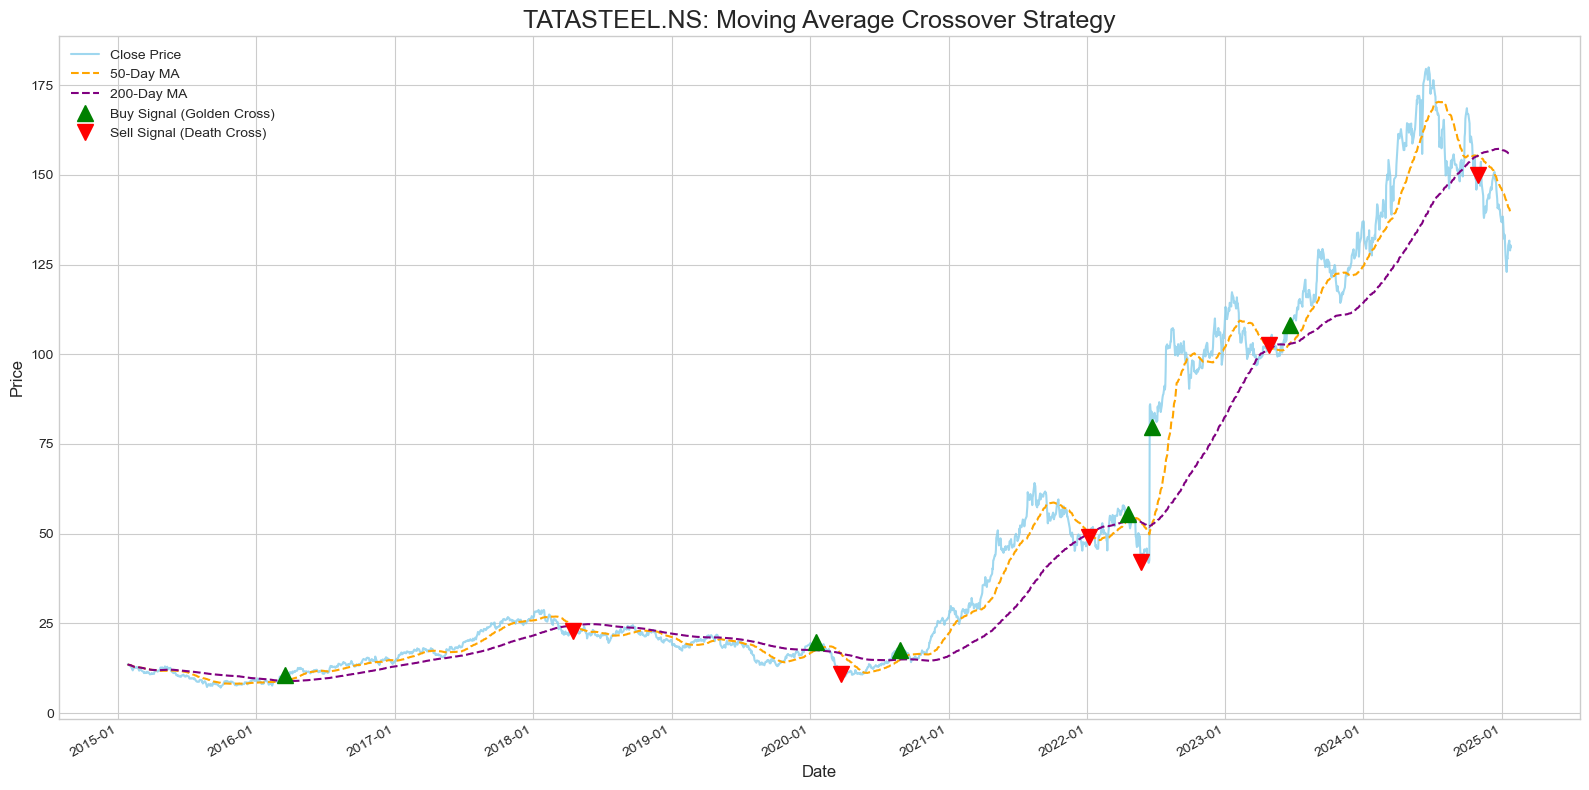

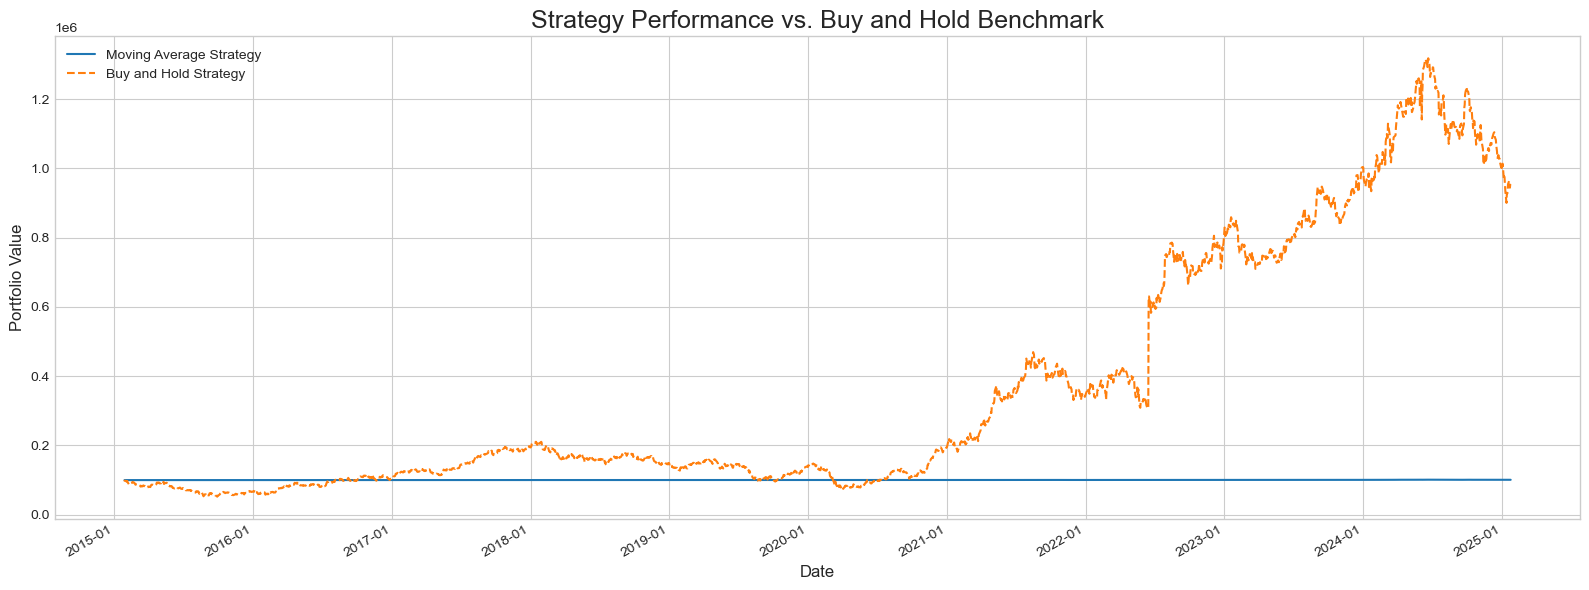

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Load the cleaned dataset
df = pd.read_csv('stock_prices_cleaned.csv')

#      Data Preparation     
# Convert 'trade_date' to datetime objects for proper plotting and analysis
df['trade_date'] = pd.to_datetime(df['trade_date'])
# Sort the dataframe by date to ensure calculations are in the correct order
df = df.sort_values('trade_date').reset_index(drop=True)

#      Strategy Implementation for a single stock     
# We'll backtest the strategy on TATASTEEL.NS
stock_df = df[df['stock_symbol'] == 'TATASTEEL.NS'].copy()

#      Generate Trading Signals
# A signal of 1 is generated when the 50-day MA is greater than the 200-day MA (uptrend).
# A signal of 0 is generated otherwise (downtrend).
stock_df['signal'] = np.where(stock_df['ma_50'] > stock_df['ma_200'], 1, 0)

# The 'position' is the change in the signal from the previous day.
# A change from 0 to 1 is a buy signal (position = 1).
# A change from 1 to 0 is a sell signal (position = -1).
stock_df['position'] = stock_df['signal'].diff()

# Visualization of Signals
plt.style.use('seaborn-v0_8-whitegrid')
fig, ax = plt.subplots(figsize=(16, 8))

# Plot the closing price and the moving averages
ax.plot(stock_df['trade_date'], stock_df['close_price'], label='Close Price', color='skyblue', alpha=0.8)
ax.plot(stock_df['trade_date'], stock_df['ma_50'], label='50-Day MA', color='orange', linestyle='--')
ax.plot(stock_df['trade_date'], stock_df['ma_200'], label='200-Day MA', color='purple', linestyle='--')

# Plot the Buy Signals (Golden Cross)
buy_signals = stock_df[stock_df['position'] == 1]
ax.plot(buy_signals['trade_date'], buy_signals['close_price'], '^', markersize=12, color='green', label='Buy Signal (Golden Cross)')

# Plot the Sell Signals (Death Cross)
sell_signals = stock_df[stock_df['position'] == -1]
ax.plot(sell_signals['trade_date'], sell_signals['close_price'], 'v', markersize=12, color='red', label='Sell Signal (Death Cross)')

# Formatting the plot for clarity
ax.set_title('TATASTEEL.NS: Moving Average Crossover Strategy', fontsize=18)
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Price', fontsize=12)
ax.legend(loc='upper left', fontsize=10)
ax.grid(True)
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.gca().xaxis.set_major_locator(mdates.YearLocator())
plt.gcf().autofmt_xdate()
plt.tight_layout()
plt.savefig('trading_strategy_visualization.png')
print("Generated plot: Trading Strategy Visualization")

# Performance Calculation
initial_capital = 100000.0
# Create a DataFrame to track our positions (number of shares)
positions = pd.DataFrame(index=stock_df.index).fillna(0.0)
# Create a DataFrame to track our portfolio value
portfolio = pd.DataFrame(index=stock_df.index).fillna(0.0)

# Buy 10 shares when the signal is 1 (in an uptrend)
positions['shares'] = 10 * stock_df['signal']
# Calculate the cash value of our stock holdings
portfolio['holdings'] = positions['shares'] * stock_df['close_price']
# Calculate the cash we have on hand
portfolio['cash'] = initial_capital - (positions.diff()['shares'] * stock_df['close_price']).cumsum()
# Total portfolio value is cash + holdings
portfolio['total'] = portfolio['cash'] + portfolio['holdings']
# Calculate the daily returns of our strategy
portfolio['returns'] = portfolio['total'].pct_change()


# Benchmark: Buy and Hold Strategy
benchmark_df = pd.DataFrame(index=stock_df.index)
# Calculate how many shares we could buy with our initial capital on day one
benchmark_df['shares_to_buy'] = np.floor(initial_capital / stock_df['close_price'].iloc[0])
# Calculate the value of that holding over time
benchmark_df['total'] = benchmark_df['shares_to_buy'] * stock_df['close_price']


# Plot Performance Comparison
fig2, ax2 = plt.subplots(figsize=(16, 6))

ax2.plot(stock_df['trade_date'], portfolio['total'], label='Moving Average Strategy')
ax2.plot(stock_df['trade_date'], benchmark_df['total'], label='Buy and Hold Strategy', linestyle='--')
ax2.set_title('Strategy Performance vs. Buy and Hold Benchmark', fontsize=18)
ax2.set_xlabel('Date', fontsize=12)
ax2.set_ylabel('Portfolio Value', fontsize=12)
ax2.legend(loc='upper left', fontsize=10)
ax2.grid(True)
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.gca().xaxis.set_major_locator(mdates.YearLocator())
plt.gcf().autofmt_xdate()
plt.tight_layout()
plt.savefig('performance_comparison.png')
print("Generated plot: Performance Comparison")

# Final Results
print("\n     Backtest Results     ")
print("Final Portfolio Value (MA Crossover Strategy): ${:,.2f}".format(portfolio['total'].iloc[-1]))
print("Final Portfolio Value (Buy and Hold): ${:,.2f}".format(benchmark_df['total'].iloc[-1]))
